## How to use this notebook

This notebook applies the updated engineering damage workflow. It still assigns HAZUS bridge classes for reporting, but the damage-state probabilities now use the revised SVI-driven fragility methodology:

- the updated SVI weights and scoring rules are computed first
- SVI determines fragility medians for each damage state
- fragility dispersion is also updated using the SVI-based uncertainty expression
- PGA is combined with those SVI-driven fragility parameters to produce `P_DS0` to `P_DS4` and `EDR`

**Input**
- `data/processed/pga_nbi_bridge.csv`

**Output**
- `data/processed/bridges_with_edr.csv`

**Why this step matters**
This notebook is now the bridge between intrinsic vulnerability scoring (`SVI`) and event-specific shaking demand (`PGA`).

**Next notebook**
After this notebook, run `svi.ipynb` if you want to inspect the SVI table directly, then continue to `MachineLearning.ipynb`.

# Part 2: HAZUS Classification, SVI-Driven Fragility Probabilities, and Expected Damage Ratio

This part of the workflow reads the bridge inventory with sampled PGA values, rebuilds the updated SVI methodology, assigns HAZUS bridge classes for reporting, and then computes damage-state probabilities using SVI-dependent fragility medians and dispersion. The result is an Expected Damage Ratio (`EDR`) that reflects both intrinsic bridge vulnerability and event shaking demand.

The output of this step is a bridge-level dataset containing:
- simplified bridge features
- HAZUS bridge class
- updated SVI component scores
- SVI-driven fragility parameters
- damage-state probabilities
- Expected Damage Ratio

In [1]:
from runtime_checks import ensure_packages, ensure_supported_runtime

ensure_supported_runtime()
ensure_packages([
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "sklearn",
    "rasterio",
    "geopandas",
    "shapely",
    "seaborn",
    "rasterstats",
])

print("Environment check passed. Use a local Python kernel from the project environment.")


Environment check passed. Use a local Python kernel from the project environment.


In [2]:
from pathlib import Path

In [3]:
import pandas as pd

from project_paths import build_paths, require_paths
from svi_methodology import (
    DEFAULT_FRAGILITY_MEDIAN_METHOD,
    clean_kind_series,
    compute_damage_probabilities,
)
from scripts.run_ml_hybrid_analysis import assign_hwb_class

PATHS = build_paths()
INPUT_CSV = PATHS["PGA_BRIDGE_CSV"]
OUT_EDR_CSV = PATHS["EDR_CSV"]

require_paths(PATHS, ["PGA_BRIDGE_CSV"])

bridge_df = pd.read_csv(INPUT_CSV, low_memory=False)
bridge_df["kind"] = clean_kind_series(bridge_df["STRUCTURE_KIND_043A"])
bridge_df["type"] = clean_kind_series(bridge_df["STRUCTURE_TYPE_043B"])
bridge_df["HWB_CLASS"] = bridge_df.apply(assign_hwb_class, axis=1)

bridge_df = compute_damage_probabilities(
    bridge_df,
    median_method=DEFAULT_FRAGILITY_MEDIAN_METHOD,
)

bridge_df.to_csv(OUT_EDR_CSV, index=False)
print(bridge_df[[
    "STRUCTURE_NUMBER_008",
    "pga",
    "HWB_CLASS",
    "SVI",
    "YR_MULTIPLIER",
    "BETA_SVI",
    "P_DS0",
    "P_DS1",
    "P_DS2",
    "P_DS3",
    "P_DS4",
    "EDR",
]].head())
print("Saved:", OUT_EDR_CSV)

  STRUCTURE_NUMBER_008       pga HWB_CLASS     P_DS0     P_DS1     P_DS2  \
1              1CA0070  0.177764      HWB2  0.577864  0.333897  0.082150   
2              1CA0095  0.028422      HWB5  0.999676  0.000322  0.000002   
3              1CA0141  0.183217      HWB2  0.558068  0.345357  0.089561   
4              1CA0142  0.183217      HWB2  0.558068  0.345357  0.089561   
5              1CA0482  0.026333      HWB6  0.999321  0.000672  0.000007   

          P_DS3         P_DS4  P_SUM       EDR  
1  4.897330e-03  1.192040e-03    1.0  0.019005  
2  7.069415e-09  3.473762e-10    1.0  0.000010  
3  5.606479e-03  1.407178e-03    1.0  0.020334  
4  5.606479e-03  1.407178e-03    1.0  0.020334  
5  1.685674e-08  6.739350e-10    1.0  0.000021  
HWB_CLASS
HWB6     5711
HWB2     2474
HWB10    1973
HWB5     1693
HWB7     1273
HWB8     1108
HWB9     1003
HWB1      967
HWB4      542
HWB3       30
Name: count, dtype: int64
count    1.679600e+04
mean     1.673191e-02
std      5.762398e-02
min    

Saved: /Users/nchatterjee/Documents/Playground/Cat-411-Project-Northridge-Bridge/data/processed/bridges_with_edr.csv


## Inference

The Part 2 results confirm that the HAZUS-based bridge fragility workflow was implemented successfully. Each bridge was assigned a HAZUS bridge class using structural inventory information, and the resulting class distribution shows that the dataset contains a meaningful variety of bridge categories. This indicates that the classification logic did not collapse the dataset into only one or two structural types.

The computed damage-state probabilities are also internally consistent, as their sums equal 1.0 for the evaluated bridges. This confirms that the exceedance probabilities were correctly transformed into discrete probabilities for no damage, slight, moderate, extensive, and complete damage.

The Expected Damage Ratio values are generally low for most bridges, which is reasonable because only a smaller subset of bridges is exposed to stronger shaking. At the same time, the presence of higher EDR values for some bridges shows that the method is capturing damage concentration in more severely affected locations. Overall, this step provides a valid engineering-based benchmark of seismic bridge damage that can later be compared with SVI scoring and machine learning results.

 # Part 2 Plots: HAZUS Class Distribution, Expected Damage Ratio, and PGA–EDR Relationship

These plots are used to examine the outputs of the HAZUS-based fragility workflow. The class distribution plot shows how bridges were assigned across different HAZUS bridge categories. This helps confirm that the bridge classification logic produced a meaningful structural breakdown.

The Expected Damage Ratio histogram shows the overall damage severity pattern across the bridge dataset. Since earthquake damage is usually concentrated in a smaller subset of exposed structures, a right-skewed distribution is expected.

The PGA versus EDR scatter plot is used to verify the fragility-based trend between shaking intensity and expected damage. In general, bridges subjected to stronger shaking should show higher expected damage ratios, even though structural class differences create some spread in the pattern.

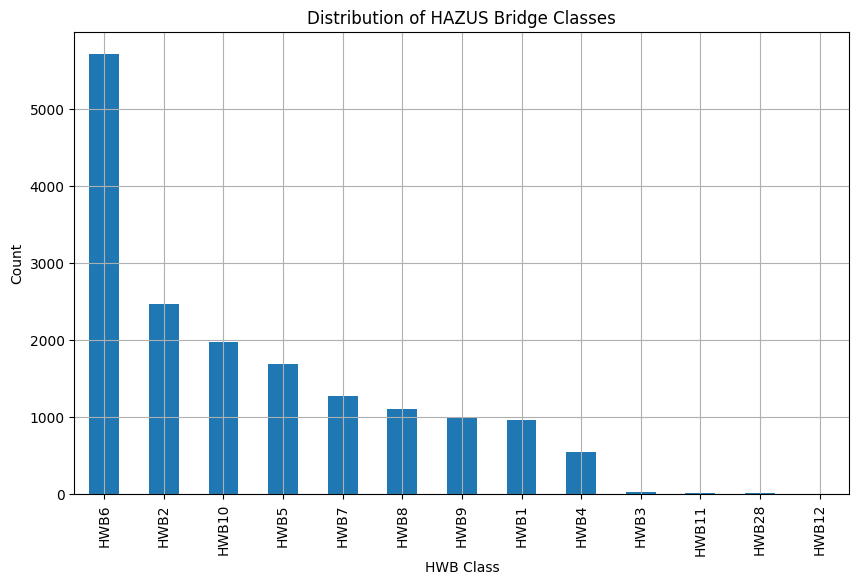

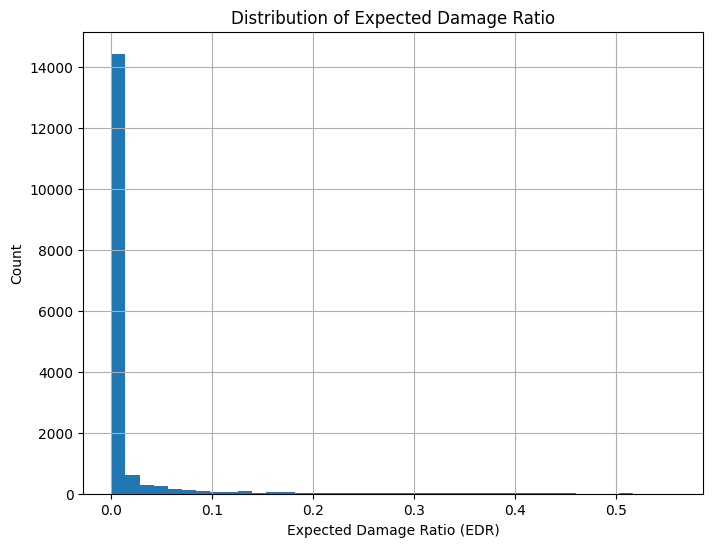

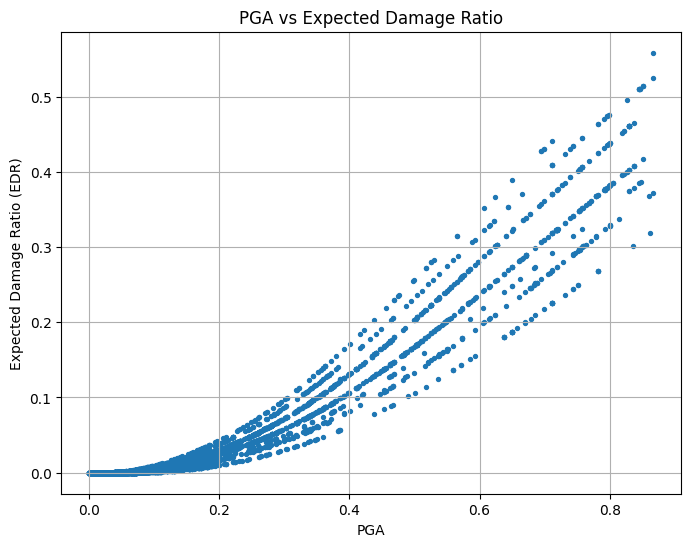

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

from project_paths import build_paths, require_paths

PATHS = build_paths()
INPUT_CSV = PATHS["EDR_CSV"]

require_paths(PATHS, ["EDR_CSV"])

bridge_df = pd.read_csv(INPUT_CSV, low_memory=False)

class_counts = bridge_df["HWB_CLASS"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
class_counts.plot(kind="bar")
plt.xlabel("HWB Class")
plt.ylabel("Count")
plt.title("Distribution of HAZUS Bridge Classes")
plt.grid(True)
plt.show()

edr_plot_df = bridge_df.dropna(subset=["EDR"]).copy()

plt.figure(figsize=(8, 6))
plt.hist(edr_plot_df["EDR"], bins=40)
plt.xlabel("Expected Damage Ratio (EDR)")
plt.ylabel("Count")
plt.title("Distribution of Expected Damage Ratio")
plt.grid(True)
plt.show()

pga_edr_df = bridge_df.dropna(subset=["pga", "EDR"]).copy()

plt.figure(figsize=(8, 6))
plt.scatter(pga_edr_df["pga"], pga_edr_df["EDR"], s=8)
plt.xlabel("PGA")
plt.ylabel("Expected Damage Ratio (EDR)")
plt.title("PGA vs Expected Damage Ratio")
plt.grid(True)
plt.show()


## Additional plot

This boxplot compares Expected Damage Ratio across HAZUS bridge classes. It helps show whether some bridge categories appear more vulnerable than others under the fragility-based damage framework.

<Figure size 1200x600 with 0 Axes>

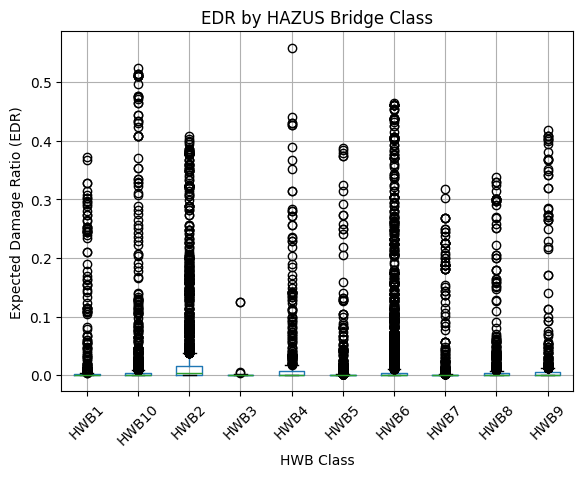

In [5]:
top_classes = bridge_df["HWB_CLASS"].value_counts().head(10).index
box_df = bridge_df[bridge_df["HWB_CLASS"].isin(top_classes)].copy()

plt.figure(figsize=(12, 6))
box_df.boxplot(column="EDR", by="HWB_CLASS", grid=True)
plt.xlabel("HWB Class")
plt.ylabel("Expected Damage Ratio (EDR)")
plt.title("EDR by HAZUS Bridge Class")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()

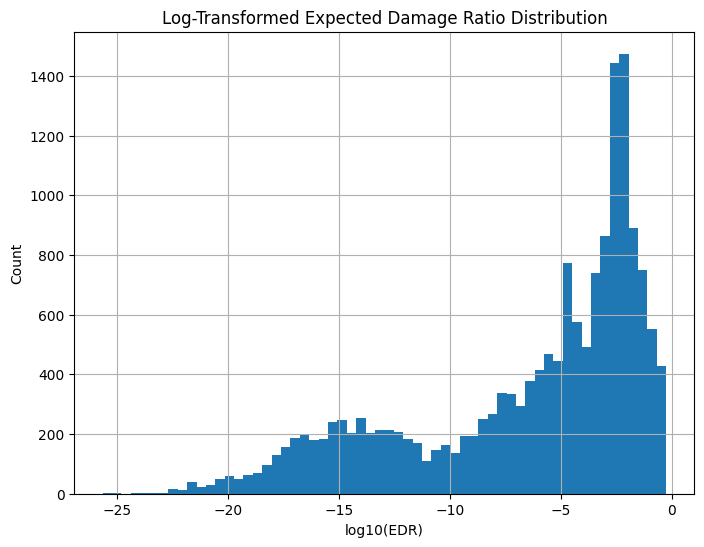

In [6]:
edr_vals = bridge_df["EDR"].dropna()
edr_vals = edr_vals[edr_vals > 0]

plt.figure(figsize=(8, 6))
plt.hist(np.log10(edr_vals), bins=60)
plt.xlabel("log10(EDR)")
plt.ylabel("Count")
plt.title("Log-Transformed Expected Damage Ratio Distribution")
plt.grid(True)
plt.show()

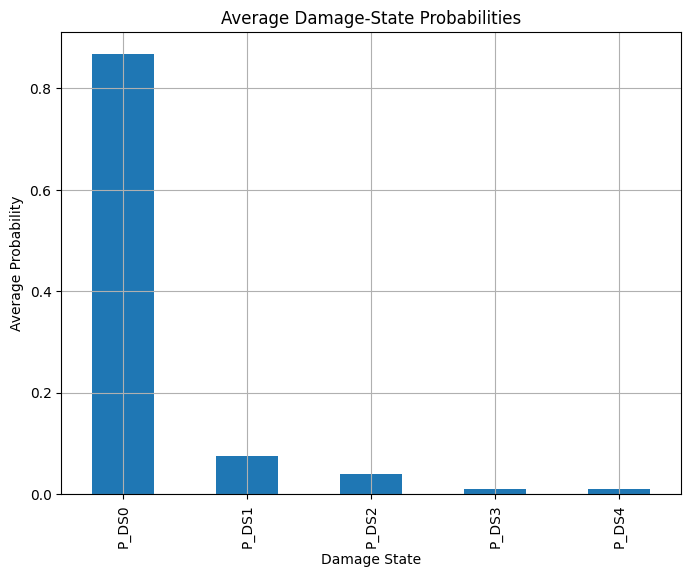

In [7]:
damage_cols = ["P_DS0", "P_DS1", "P_DS2", "P_DS3", "P_DS4"]
mean_probs = bridge_df[damage_cols].mean()

plt.figure(figsize=(8, 6))
mean_probs.plot(kind="bar")
plt.xlabel("Damage State")
plt.ylabel("Average Probability")
plt.title("Average Damage-State Probabilities")
plt.grid(True)
plt.show()

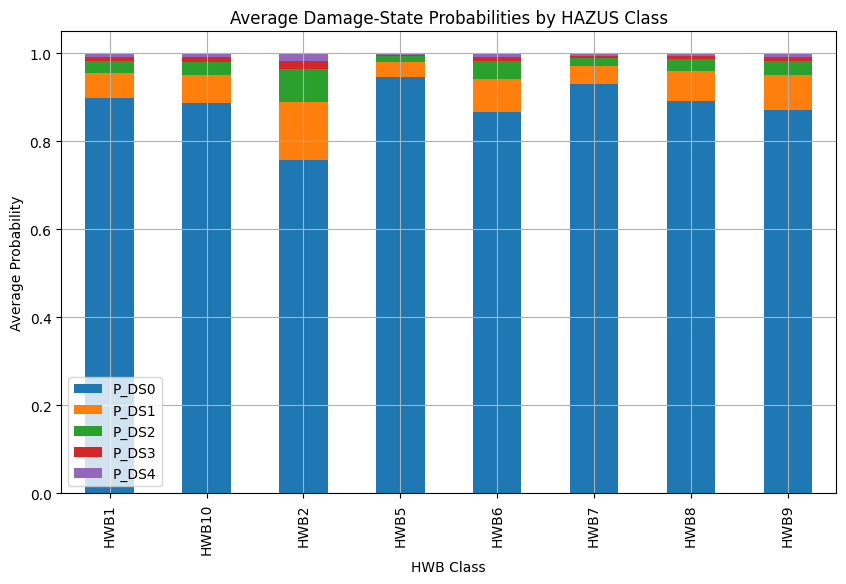

In [8]:
damage_cols = ["P_DS0", "P_DS1", "P_DS2", "P_DS3", "P_DS4"]
top_classes = bridge_df["HWB_CLASS"].value_counts().head(8).index

class_damage = (
    bridge_df[bridge_df["HWB_CLASS"].isin(top_classes)]
    .groupby("HWB_CLASS")[damage_cols]
    .mean()
)

class_damage.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.xlabel("HWB Class")
plt.ylabel("Average Probability")
plt.title("Average Damage-State Probabilities by HAZUS Class")
plt.grid(True)
plt.show()

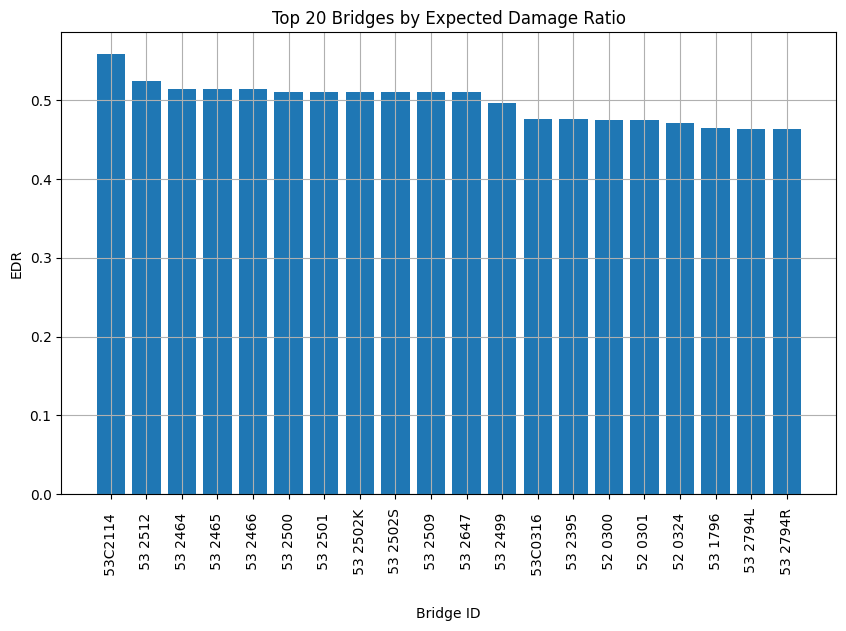

In [9]:
top_risk = bridge_df.nlargest(20, "EDR")[["STRUCTURE_NUMBER_008", "HWB_CLASS", "pga", "EDR"]]

plt.figure(figsize=(10, 6))
plt.bar(top_risk["STRUCTURE_NUMBER_008"], top_risk["EDR"])
plt.xlabel("Bridge ID")
plt.ylabel("EDR")
plt.title("Top 20 Bridges by Expected Damage Ratio")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

## Inference

The Part 2 plots confirm that the HAZUS-based fragility workflow is behaving as expected. The HAZUS bridge class distribution shows that the bridge inventory was divided across multiple structural categories, with some classes such as HWB6, HWB2, and HWB10 appearing much more frequently than others. This indicates that the classification logic captured meaningful variation in bridge type rather than assigning nearly all bridges to the same class.

The Expected Damage Ratio histogram is strongly right-skewed, which suggests that most bridges experience relatively low expected damage while only a smaller subset reaches moderate or high damage levels. This is consistent with earthquake damage behavior, where severe impacts are concentrated among the most exposed or vulnerable bridges.

The PGA versus EDR scatter plot shows a clear positive relationship between shaking intensity and expected damage. As PGA increases, EDR also increases, which is exactly what should happen under a fragility-based seismic damage framework. The banded pattern in the scatter is also reasonable because different HAZUS bridge classes have different fragility parameters, so bridges with similar PGA can still have different expected damage levels.

The EDR-by-class plot further supports this interpretation by showing that some HAZUS classes tend to produce higher damage ratios and more variability than others. Overall, these plots validate the engineering-based benchmark and provide a strong foundation for comparing HAZUS outputs with later SVI and machine learning results.

## 

The plot of the top 20 bridges by Expected Damage Ratio highlights the subset of bridges with the greatest predicted seismic damage. Their EDR values cluster around the upper end of the observed range, which indicates that the HAZUS fragility framework is identifying a small group of bridges that are much more at risk than the rest of the inventory. This kind of ranking is useful for inspection prioritization and shows how the damage results can be turned into decision-support outputs.

The average damage-state probability plot shows that the no-damage state, P_DS0, dominates across the full bridge dataset, while the probabilities of slight, moderate, extensive, and complete damage are much smaller on average. This is expected because most bridges are located in lower shaking zones, while only a smaller portion is exposed to higher seismic demand. Together, these plots reinforce that the fragility workflow is producing realistic system-level damage patterns while still identifying the most critical bridges within the dataset.